In [66]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import kagglehub
import seaborn as sns
import sklearn as skl
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

sns.set_theme(style='whitegrid')

In [12]:
teldf = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(f"Dataset shape: {teldf.shape}")
teldf.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
### Checking data types
teldf.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [14]:
### Unusual data type for Totalcharges, expecting dollar amount to be a float
print(teldf["TotalCharges"].dtype)

str


In [20]:
### If string data type, possibility of empty entries?
empties = teldf["TotalCharges"].astype(str).str.strip() == ""

In [23]:
### Indices where TotalCharges entry is empty
np.where(empties == True)

(array([ 488,  753,  936, 1082, 1340, 3331, 3826, 4380, 5218, 6670, 6754]),)

In [25]:
teldf.loc[empties].head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No


In [51]:
### Let's set empty entries to NaN's for computation later
teldf['TotalCharges'] = pd.to_numeric(teldf['TotalCharges'], errors='coerce')

In [52]:
### Causal correlation between tenure months and TotalCharges --> brand new customers
### Changing TotalCharges to 0. 
teldf['TotalCharges'] = teldf['TotalCharges'].fillna(0.0)

### Target balance: let's inspect how "balanced" the churn rate is for the current customer base

In [53]:
teldf["ChurnBinary"] = (teldf["Churn"] == "Yes").astype(int)
balance = teldf["Churn"].value_counts(normalize = True)

In [54]:
balance

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

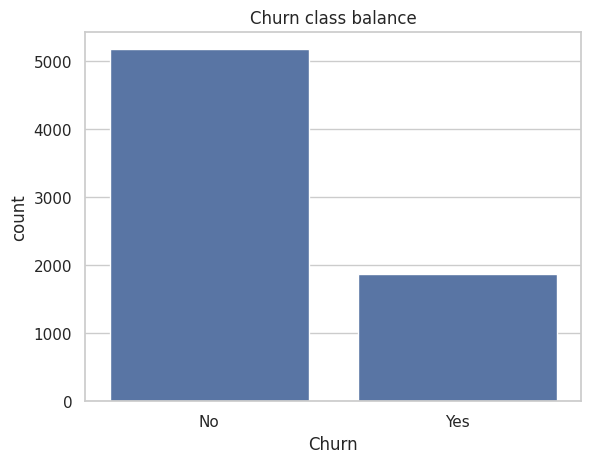

In [55]:
sns.countplot(data=teldf, x='Churn')
plt.title('Churn class balance')
plt.show()

In [56]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Summary stats by churn
summary = teldf.groupby('Churn')[num_cols].agg(['mean', 'median', 'std'])
summary

tenure                   MonthlyCharges                     \
            mean median        std           mean  median        std   
Churn                                                                  
No     37.569965   38.0  24.113777      61.265124  64.425  31.092648   
Yes    17.979133   10.0  19.531123      74.441332  79.650  24.666053   

      TotalCharges                         
              mean    median          std  
Churn                                      
No     2549.911442  1679.525  2329.954215  
Yes    1531.796094   703.550  1890.822994

***
### Now implement gradient boosting models for logistic regression:

In [76]:
X = teldf.drop(columns = ["Churn","ChurnBinary","customerID"])
y = teldf["ChurnBinary"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y)

In [77]:
print("Train shape:", X_train.shape, "\nTest shape:", X_test.shape)
print("Train churn rate:", round(y_train.mean(), 4),"\nTest churn rate:", round(y_test.mean(), 4))

Train shape: (5634, 19) 
Test shape: (1409, 19)
Train churn rate: 0.2654 
Test churn rate: 0.2654
